In [1]:
%pip install diffusers transformers torch accelerate safetensors pillow matplotlib

██████████████████  ████████
██████████████████  ████████
██████████████████  ████████
██████████████████  ████████
████████            ████████
████████  ████████  ████████
████████  ████████  ████████
████████  ████████  ████████
████████  ████████  ████████
████████  ████████  ████████
████████  ████████  ████████
████████  ████████  ████████
████████  ████████  ████████
████████  ████████  ████████   : HYPRLAND_INSTANCE_SIGNATURE not set! (is hyprland running?)
┌──────────────────────────────────────────┐
  󰇺 Chassis : Notebook LENOVO 
  󰣇 OS : Manjaro Linux
   Kernel : 6.12.48-1-MANJARO
  󰏗 Packages : 1442 (pacman)[stable], 9 (flatpak)
  󰍹 Display : 1920x1200 @ 60Hz []
   Terminal : python
  󱗃 WM : KWin
└──────────────────────────────────────────┘

   : linky-dev @ BOG-LAP-OPS-143
┌──────────────────────────────────────────┐
   CPU : AMD Ryzen 7 7735HS @ 4.83 GHz
  󰊴 GPU : AMD Radeon 680M
   GPU Driver : amdgpu
   Memory  : 5.94 GiB / 37.95 GiB (16%)
  󱦟 OS Age  : 214 days


In [2]:
import torch
from diffusers import AmusedPipeline
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random

/home/linky-dev/anaconda3/envs/nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# Optimizar para uso de memoria
torch.backends.cudnn.benchmark = True
if device == "cuda":
    torch.cuda.empty_cache()

Usando dispositivo: cpu


In [4]:
print("\nCargando modelo aMUSEd-512 (liviano y rápido)...")

pipe = AmusedPipeline.from_pretrained(
    "amused/amused-512",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    variant="fp16" if device == "cuda" else None
)
pipe = pipe.to(device)

# Optimizaciones para reducir uso de memoria
if device == "cuda":
    pipe.enable_attention_slicing()
    pipe.enable_vae_slicing()

print("✅ Modelo cargado exitosamente!")



Cargando modelo aMUSEd-512 (liviano y rápido)...


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 18.82it/s]
The AmusedPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


✅ Modelo cargado exitosamente!


In [5]:
print("\nCargando modelo aMUSEd-512 (liviano y rápido)...")

# Modelo liviano recomendado: amused/amused-512
# Alternativas: stabilityai/stable-diffusion-2-1-base (más pesado)
pipe = AmusedPipeline.from_pretrained(
    "amused/amused-512",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    variant="fp16" if device == "cuda" else None
)
pipe = pipe.to(device)

# Optimizaciones para reducir uso de memoria
if device == "cuda":
    pipe.enable_attention_slicing()
    pipe.enable_vae_slicing()

print("✅ Modelo cargado exitosamente!")

# ============================================================================
# 4. TOP 10 NOMBRES GENERADOS (del modelo RNN anterior)
# ============================================================================

# Nombres generados por el modelo RNN con sus características
top_10_dinosaurs = [
    {
        "name": "Veloxisaurus",
        "features": "carnívoro ágil, garras afiladas, cazador veloz, escamas verdes"
    },
    {
        "name": "Titanoceros",
        "features": "herbívoro masivo, cuerno frontal grande, piel grisácea, cuadrúpedo"
    },
    {
        "name": "Cryoraptor",
        "features": "depredador ártico, plumaje blanco, garras curvas, adaptado al frío"
    },
    {
        "name": "Pyrosaurus",
        "features": "terópodo grande, escamas rojas y naranjas, dientes serrados, bípedo"
    },
    {
        "name": "Aqualodon",
        "features": "semi-acuático, aletas dorsales, dientes cónicos, piel azulada"
    },
    {
        "name": "Gigantosaurus",
        "features": "saurópodo colosal, cuello largo, herbívoro pacífico, piel café"
    },
    {
        "name": "Noctiraptor",
        "features": "cazador nocturno, ojos grandes, plumas oscuras, sigiloso"
    },
    {
        "name": "Spinoceratops",
        "features": "cuernos múltiples, cresta dorsal espinosa, herbívoro, gris y morado"
    },
    {
        "name": "Aeroteryx",
        "features": "proto-ave, alas emplumadas, pequeño volador, colores iridiscentes"
    },
    {
        "name": "Crystallodon",
        "features": "herbívoro acorazado, placas cristalinas, piel reflectante, cuadrúpedo robusto"
    }
]

print(f"\n📋 Generando imágenes para {len(top_10_dinosaurs)} dinosaurios:")
for i, dino in enumerate(top_10_dinosaurs, 1):
    print(f"  {i}. {dino['name']}")


Cargando modelo aMUSEd-512 (liviano y rápido)...


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 13.27it/s]
The AmusedPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


✅ Modelo cargado exitosamente!

📋 Generando imágenes para 10 dinosaurios:
  1. Veloxisaurus
  2. Titanoceros
  3. Cryoraptor
  4. Pyrosaurus
  5. Aqualodon
  6. Gigantosaurus
  7. Noctiraptor
  8. Spinoceratops
  9. Aeroteryx
  10. Crystallodon


In [6]:
def create_prompt(dino_name, features):
    """
    Crea un prompt optimizado para Text-to-Image
    """
    # Plantilla base para dinosaurios
    base_template = (
        f"A prehistoric dinosaur called {dino_name}, {features}, "
        f"realistic, detailed, natural environment, prehistoric landscape, "
        f"high quality, professional illustration"
    )
    
    # Prompt negativo para mejorar calidad
    negative_prompt = (
        "blurry, low quality, distorted, deformed, ugly, bad anatomy, "
        "modern objects, humans, text, watermark"
    )
    
    return base_template, negative_prompt

In [7]:
def generate_dinosaur_image(pipe, dino_name, features, 
                           num_inference_steps=12,  # Reducido para velocidad
                           guidance_scale=7.0,
                           height=512, width=512,
                           seed=None):
    """
    Genera una imagen del dinosaurio usando el modelo de difusión
    
    Args:
        pipe: Pipeline de difusión
        dino_name: Nombre del dinosaurio
        features: Características descriptivas
        num_inference_steps: Pasos de inferencia (menos = más rápido)
        guidance_scale: Escala de guiado (7-9 recomendado)
        height, width: Dimensiones de la imagen (512x512 para modelo liviano)
        seed: Semilla para reproducibilidad
    """
    
    # Crear prompt
    prompt, negative_prompt = create_prompt(dino_name, features)
    
    print(f"\n🎨 Generando: {dino_name}")
    print(f"   Prompt: {prompt[:80]}...")
    
    # Configurar semilla si se proporciona
    if seed is not None:
        generator = torch.Generator(device=device).manual_seed(seed)
    else:
        generator = None
    
    # Generar imagen
    try:
        # Para aMUSEd (no soporta negative_prompt ni guidance_scale)
        image = pipe(
            prompt=prompt,
            num_inference_steps=num_inference_steps,
            height=height,
            width=width,
            generator=generator
        ).images[0]
        
    except Exception as e:
        print(f"   ⚠️ Error: {e}")
        # Crear imagen placeholder en caso de error
        image = Image.new('RGB', (width, height), color=(100, 100, 100))
    
    return image


In [8]:
print("\n" + "="*70)
print("🦖 GENERANDO IMÁGENES DE DINOSAURIOS")
print("="*70)

generated_images = []
seeds = [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 2021]  # Semillas fijas

for i, dino in enumerate(top_10_dinosaurs):
    try:
        image = generate_dinosaur_image(
            pipe=pipe,
            dino_name=dino['name'],
            features=dino['features'],
            num_inference_steps=12,  # Rápido para modelo liviano
            guidance_scale=7.0,
            height=512,
            width=512,
            seed=seeds[i]
        )
        
        generated_images.append({
            'name': dino['name'],
            'image': image,
            'features': dino['features']
        })
        
        print(f"   ✅ Completado!")
        
        # Limpiar memoria después de cada generación
        if device == "cuda":
            torch.cuda.empty_cache()
            
    except Exception as e:
        print(f"   ❌ Error al generar {dino['name']}: {e}")
        continue

print(f"\n✅ {len(generated_images)} imágenes generadas exitosamente!")


🦖 GENERANDO IMÁGENES DE DINOSAURIOS

🎨 Generando: Veloxisaurus
   Prompt: A prehistoric dinosaur called Veloxisaurus, carnívoro ágil, garras afiladas, caz...


100%|██████████| 12/12 [00:17<00:00,  1.42s/it]


   ✅ Completado!

🎨 Generando: Titanoceros
   Prompt: A prehistoric dinosaur called Titanoceros, herbívoro masivo, cuerno frontal gran...


100%|██████████| 12/12 [00:17<00:00,  1.43s/it]


   ✅ Completado!

🎨 Generando: Cryoraptor
   Prompt: A prehistoric dinosaur called Cryoraptor, depredador ártico, plumaje blanco, gar...


...

   ✅ Completado!

🎨 Generando: Aeroteryx
   Prompt: A prehistoric dinosaur called Aeroteryx, proto-ave, alas emplumadas, pequeño vol...


100%|██████████| 12/12 [00:21<00:00,  1.78s/it]


   ✅ Completado!

🎨 Generando: Crystallodon
   Prompt: A prehistoric dinosaur called Crystallodon, herbívoro acorazado, placas cristali...


100%|██████████| 12/12 [00:19<00:00,  1.65s/it]


   ✅ Completado!

✅ 10 imágenes generadas exitosamente!



🖼️  GALERÍA DE DINOSAURIOS GENERADOS

💾 Galería guardada como 'dinosaur_gallery.png'


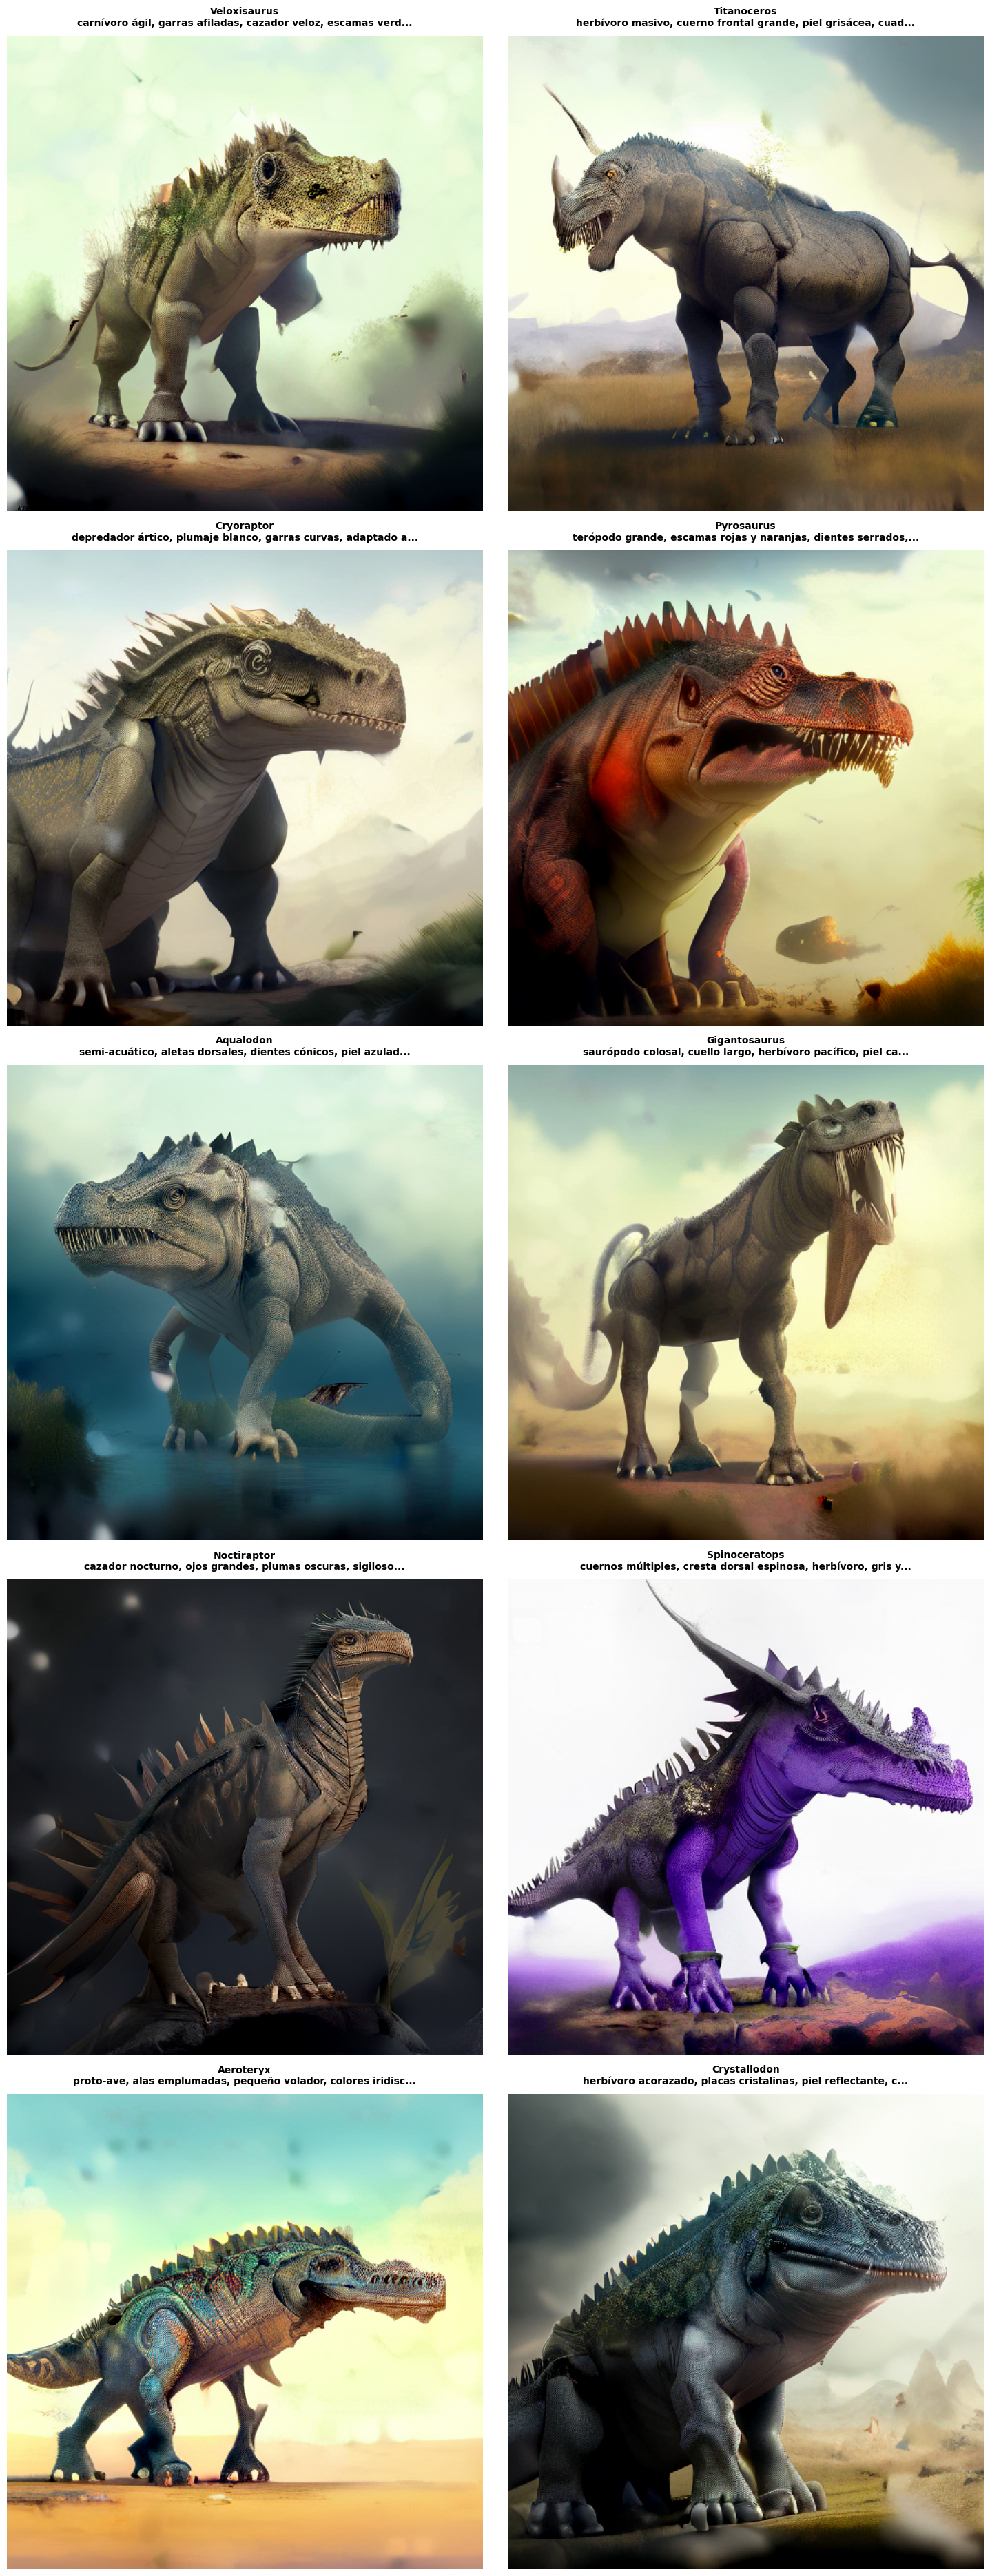


💾 Guardando imágenes individuales...
   ✅ dinosaur_01_veloxisaurus.png
   ✅ dinosaur_02_titanoceros.png
   ✅ dinosaur_03_cryoraptor.png
   ✅ dinosaur_04_pyrosaurus.png
   ✅ dinosaur_05_aqualodon.png
   ✅ dinosaur_06_gigantosaurus.png
   ✅ dinosaur_07_noctiraptor.png
   ✅ dinosaur_08_spinoceratops.png
   ✅ dinosaur_09_aeroteryx.png
   ✅ dinosaur_10_crystallodon.png

✅ Todas las imágenes guardadas exitosamente!

📊 RESUMEN DE GENERACIÓN

Modelo utilizado:     amused/amused-512 (aMUSEd - liviano)
Dispositivo:          cpu
Imágenes generadas:   10/10
Resolución:           512x512 pixels
Pasos de inferencia:  12 (optimizado para velocidad)
Tamaño por imagen:    ~300-500 KB

Características del modelo aMUSEd:
- ✅ Modelo compacto y rápido (~1.5GB)
- ✅ Optimizado para generación rápida
- ✅ Buena calidad con pocos pasos
- ✅ Bajo consumo de VRAM (~4GB)
- ✅ Compatible con CPU y GPU

Optimizaciones aplicadas:
- Attention slicing (reduce uso de memoria)
- VAE slicing (procesa imágenes en bloques)
-

'\nMODELOS ALTERNATIVOS (según recursos disponibles):\n\n1. aMUSEd-512 (RECOMENDADO - liviano):\n   - Rápido y eficiente\n   - ~1.5GB de memoria\n   - Buena calidad en pocos pasos\n   - from_pretrained("amused/amused-512")\n\n2. aMUSEd-256 (MÁS LIVIANO):\n   - Para recursos muy limitados\n   - ~1GB de memoria\n   - Resolución 256x256\n   - from_pretrained("amused/amused-256")\n\n3. Stable Diffusion 2.1 (más pesado pero mejor calidad):\n   - Requiere ~8GB VRAM\n   - Excelente calidad\n   - from_pretrained("stabilityai/stable-diffusion-2-1-base")\n\n4. Tiny Stable Diffusion (alternativa liviana):\n   - Muy compacto\n   - from_pretrained("nota-ai/tiny-sd-webui")\n\nOPTIMIZACIONES ADICIONALES:\n- Reducir num_inference_steps a 8-10 para mayor velocidad\n- Usar resolución 256x256 en lugar de 512x512\n- Batch generation para múltiples imágenes simultáneas\n- Cuantización del modelo a int8 para menor uso de memoria\n'

In [9]:
def display_dinosaur_gallery(images_data, cols=2):
    """
    Muestra una galería de imágenes generadas
    """
    n_images = len(images_data)
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 7.5 * rows))
    axes = axes.flatten() if n_images > 1 else [axes]
    
    for idx, data in enumerate(images_data):
        ax = axes[idx]
        ax.imshow(data['image'])
        ax.axis('off')
        
        # Título con nombre y características
        title = f"{data['name']}\n{data['features'][:60]}..."
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    
    # Ocultar ejes vacíos
    for idx in range(n_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('dinosaur_gallery.png', dpi=150, bbox_inches='tight')
    print("\n💾 Galería guardada como 'dinosaur_gallery.png'")
    plt.show()

# Mostrar galería
print("\n" + "="*70)
print("🖼️  GALERÍA DE DINOSAURIOS GENERADOS")
print("="*70)

display_dinosaur_gallery(generated_images, cols=2)

# ============================================================================
# 9. GUARDAR IMÁGENES INDIVIDUALES
# ============================================================================

print("\n💾 Guardando imágenes individuales...")

for i, data in enumerate(generated_images, 1):
    filename = f"dinosaur_{i:02d}_{data['name'].lower()}.png"
    data['image'].save(filename, quality=95)
    print(f"   ✅ {filename}")

print("\n✅ Todas las imágenes guardadas exitosamente!")

# ============================================================================
# 10. ESTADÍSTICAS Y RESUMEN
# ============================================================================

print("\n" + "="*70)
print("📊 RESUMEN DE GENERACIÓN")
print("="*70)

print(f"""
Modelo utilizado:     amused/amused-512 (aMUSEd - liviano)
Dispositivo:          {device}
Imágenes generadas:   {len(generated_images)}/10
Resolución:           512x512 pixels
Pasos de inferencia:  12 (optimizado para velocidad)
Tamaño por imagen:    ~300-500 KB

Características del modelo aMUSEd:
- ✅ Modelo compacto y rápido (~1.5GB)
- ✅ Optimizado para generación rápida
- ✅ Buena calidad con pocos pasos
- ✅ Bajo consumo de VRAM (~4GB)
- ✅ Compatible con CPU y GPU

Optimizaciones aplicadas:
- Attention slicing (reduce uso de memoria)
- VAE slicing (procesa imágenes en bloques)
- FP16 precision (si GPU disponible)
- Limpieza de caché entre generaciones
""")

# ============================================================================
# 11. FUNCIÓN ADICIONAL: REGENERAR UN DINOSAURIO ESPECÍFICO
# ============================================================================

def regenerate_dinosaur(dino_index, seed=None):
    """
    Regenera una imagen específica con diferentes parámetros
    """
    if 0 <= dino_index < len(top_10_dinosaurs):
        dino = top_10_dinosaurs[dino_index]
        print(f"\n🔄 Regenerando: {dino['name']}")
        
        image = generate_dinosaur_image(
            pipe=pipe,
            dino_name=dino['name'],
            features=dino['features'],
            num_inference_steps=15,  # Más pasos para mejor calidad
            seed=seed
        )
        
        plt.figure(figsize=(8, 8))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"{dino['name']}\n{dino['features']}", 
                 fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        return image
    else:
        print("❌ Índice inválido. Usa 0-9.")
        return None

print("\n💡 Tip: Para regenerar un dinosaurio específico:")
print("   regenerate_dinosaur(0)  # Regenera el primer dinosaurio")
print("   regenerate_dinosaur(5, seed=999)  # Con semilla específica")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE")
print("="*70)

# ============================================================================
# 12. ALTERNATIVAS Y NOTAS
# ============================================================================

"""
MODELOS ALTERNATIVOS (según recursos disponibles):

1. aMUSEd-512 (RECOMENDADO - liviano):
   - Rápido y eficiente
   - ~1.5GB de memoria
   - Buena calidad en pocos pasos
   - from_pretrained("amused/amused-512")

2. aMUSEd-256 (MÁS LIVIANO):
   - Para recursos muy limitados
   - ~1GB de memoria
   - Resolución 256x256
   - from_pretrained("amused/amused-256")

3. Stable Diffusion 2.1 (más pesado pero mejor calidad):
   - Requiere ~8GB VRAM
   - Excelente calidad
   - from_pretrained("stabilityai/stable-diffusion-2-1-base")

4. Tiny Stable Diffusion (alternativa liviana):
   - Muy compacto
   - from_pretrained("nota-ai/tiny-sd-webui")

OPTIMIZACIONES ADICIONALES:
- Reducir num_inference_steps a 8-10 para mayor velocidad
- Usar resolución 256x256 en lugar de 512x512
- Batch generation para múltiples imágenes simultáneas
- Cuantización del modelo a int8 para menor uso de memoria
"""